In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#%matplotlib inline #this gave syntax error, necessary?
plt.style.use('ggplot')
import warnings; warnings.simplefilter('ignore')


########################### on kernel Python 3 (ipykernel)
###########################
###########################

In [ ]:
## NEW VERSION of ML jupyter notebook
## STXBP1
## new VEP 110 installation with more feature annotation
## dropping Camsol to have one fewer feature requiring 

# import data
df = pd.read_csv("/projects/b1073/u54/jdc_sandbox/newRun_31jul2024/epiPredSTXBP1model4output_mergeGnomadRegeneron_31jul2024.csv", delimiter=",")

## first make a copy of dataframe before ANY further steps
df_copy = df

# Tidy data ## part 1
# dropping columns that are not used for ML

df.info()
df = df.drop(['chrom', 'ref', 'alt', 'AA_REF', 'AA_ALT'], axis=1)
df = df.drop(['AA_POS'], axis=1) ## this one could be worth trying with and without

# this is one that I'd like to include but isn't working currently
## consider revisiting this unless other in silico predictors sub in just fine
#df = df.drop(['MutPred_score'], axis=1)


############ added 15 dec 2023 ######################
# remove ALL the clinical-data-trained features
#df = df.drop(['M.CAP_score', 'MetaLR_score', 'MetaSVM_score', 'REVEL_score', 'VARITY_ER_score','VARITY_R_score', 'VEST4_score', 'fathmm.MKL_coding_score', 'gMVP_score', 'FATHMM_score', 'ClinPred_score', 'BayesDel_addAF_score', 'MPC_score'], axis=1)

# remove ONLY the ClinVar-data-specific-trained features
#df = df.drop(['REVEL_score', 'VARITY_ER_score', 'VARITY_R_score', 'gMVP_score', 'ClinPred_score', 'BayesDel_addAF_score', 'MPC_score'], axis=1)
# also remove VEST4 for responding to reviewer
df = df.drop(['REVEL_score', 'VARITY_ER_score', 'VARITY_R_score', 'gMVP_score', 'ClinPred_score', 'BayesDel_addAF_score', 'MPC_score','VEST4_score'], axis=1)
############ added 15 dec 2023 ######################

df.info()

# fix potential column naming issues
df.columns = (df.columns.str.strip().str.upper()
              .str.replace(' ', '_')
              .str.replace('(', '')
              .str.replace(')', ''))

############ added 21 mar 2024 ######################
df = df.drop(['UNNAMED:_0', 'POS','HG19_KEY','X.2','HGVS_PRO_3LETTER'], axis=1)
df = df.drop(['X.1', 'X','HGVS_PRO','BLOSUM62','EIGEN.PHRED_CODING'], axis=1)
df = df.drop(['PDB_FILE', 'CHAIN','WILD_RES','RES_POS'], axis=1)
df = df.drop(['MUT_RES', 'MAESTRODDG_CONFIDENCE','REFAA_3LETTER','ALTAA_3LETTER','AM_CLASS'], axis=1)
df = df.drop(['MUTPRED_SCORE', 'INTEGRATED_FITCONS_SCORE'], axis=1)
############ added 21 mar 2024 ######################

############ trying very simple model ######################
#df2 = df[['RSA', 'MCSM_DDG', 'AM_PATHOGENICITY', 'CLASS', 'FATHMM_SCORE','GRANTHAM_SCORE','BLOSUM62','M.CAP_SCORE','REVEL_SCORE','VARITY_R_SCORE', 'CLINPRED_SCORE','POLYPHEN2_HDIV_SCORE','VEST4_SCORE']]
############ trying very simple model ######################
#df=df2
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3943 entries, 0 to 3942
Data columns (total 73 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  3943 non-null   int64  
 1   hg19_key                    3943 non-null   object 
 2   X.2                         3943 non-null   int64  
 3   hgvs_pro_3letter            3943 non-null   object 
 4   X.1                         3943 non-null   int64  
 5   X                           3943 non-null   int64  
 6   hgvs_pro                    3943 non-null   object 
 7   chrom                       3943 non-null   int64  
 8   pos                         3943 non-null   int64  
 9   ref                         3943 non-null   object 
 10  alt                         3943 non-null   object 
 11  AA_POS                      3943 non-null   int64  
 12  AA_REF                      3943 non-null   object 
 13  AA_ALT                      3943 

In [4]:
# Tidy data ## part 2
## replace NA with median value of column
### also may need to replace '.' with NA first

df1 = df.fillna(df.median())
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3943 entries, 0 to 3942
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   HYDROPATHY_REF_SCORE        3943 non-null   int64  
 1   HYDROPATHY_ALT_SCORE        3943 non-null   int64  
 2   H_ALTMINUSREF               3943 non-null   int64  
 3   CHARGE_REF_SCORE            3943 non-null   int64  
 4   CHARGE_ALT_SCORE            3943 non-null   int64  
 5   C_ALTMINUSREF               3943 non-null   int64  
 6   POLARITY_REF_SCORE          3943 non-null   int64  
 7   POLARITY_ALT_SCORE          3943 non-null   int64  
 8   P_ALTMINUSREF               3943 non-null   int64  
 9   SHAPE_REF_SCORE             3943 non-null   int64  
 10  SHAPE_ALT_SCORE             3943 non-null   int64  
 11  S_ALTMINUSREF               3943 non-null   int64  
 12  GRANTHAM_SCORE              3943 non-null   int64  
 13  CADD_PHRED                  3943 

In [5]:
# standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

print(df1.head())

# testing a simpler method for scaling data
df1[df1.columns] = scaler.fit_transform(df1)

print(df1.head())

# fix class column
df1 = df1.drop(['CLASS'], axis=1)
df1['CLASS'] = df['CLASS']

## create another copy of scaled dataframe
dfs = df1

## subset for model training
## keep BLB (class = 0) and PLP (class = 1); remove VUS (class = 2)
df_training = df1[df1['CLASS'] <= 1]
df_training.info()

   HYDROPATHY_REF_SCORE  HYDROPATHY_ALT_SCORE  H_ALTMINUSREF  \
0                    -1                     0             -1   
1                    -1                     0             -1   
2                    -1                     0             -1   
3                    -1                     1             -2   
4                    -1                     0             -1   

   CHARGE_REF_SCORE  CHARGE_ALT_SCORE  C_ALTMINUSREF  POLARITY_REF_SCORE  \
0                 0                 0              0                   0   
1                 0                 0              0                   0   
2                 0                 0              0                   0   
3                 0                -1              1                   0   
4                 0                 0              0                   0   

   POLARITY_ALT_SCORE  P_ALTMINUSREF  SHAPE_REF_SCORE  ...  \
0                   1             -1               -1  ...   
1                   0             

In [6]:
# standard grid search ## not LOOCV
### note need to run cell below this first

import sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df_training.drop(['CLASS'], axis=1)
y = df_training['CLASS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=10)

clf = RandomForestClassifier()

param_dict = {
         #"n_estimators":[1,2,3,4,5,10,20,40,80], # also added more here -- based on 80,4 performing best across the board
         "n_estimators":[10,20,40,80,160,320,500],
         "max_depth":range(3,6)
     }
    
#cv_results_big = pd.DataFrame(np.nan, index=range(0,49), columns=['param_n_estimators', 'param_max_depth', 'mean_test_score', 'std_test_score', 'rank_test_score'])
cv_results_big = pd.DataFrame(columns = ['param_n_estimators', 'param_max_depth', 'mean_test_score', 'std_test_score', 'rank_test_score'])
#cv_results_big = pd.DataFrame()
i=0

# for NMAE ## maybe also try accuracy for scoring
## NOTE: This takes about 2 min to run 50 cycles of grid search
while i < 50:
    # random forest
    #grid_search = GridSearchCV(clf, param_grid=param_dict, cv=LeaveOneOut(),verbose=0,n_jobs=-1, scoring = 'neg_mean_absolute_error')
    
    # can't get multimetric scoring yet w LOOCV 4/3/24 - return to this 
    #grid_search = GridSearchCV(clf, param_grid=param_dict, cv=10,verbose=0,n_jobs=-1, scoring = ['neg_mean_absolute_error', 'accuracy', 'f1', 'roc_auc'], refit = 'f1', return_train_score=True)
    grid_search = GridSearchCV(clf, param_grid=param_dict, cv=5,verbose=0,n_jobs=-1, scoring = ['neg_mean_absolute_error', 'accuracy', 'f1', 'roc_auc'], refit = 'f1', return_train_score=True)
    
    grid_search.fit(X_train, y_train)
    cvres = pd.DataFrame(grid_search.cv_results_)
    
    #print(cvres)
    #print(cvres.info())
    #cv_results_tiny = cvres[['param_n_estimators', 'param_max_depth', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    
    cv_results_tiny = cvres[['param_n_estimators', 'param_max_depth', 'mean_test_neg_mean_absolute_error', 'std_test_neg_mean_absolute_error', 'rank_test_neg_mean_absolute_error', 'mean_test_accuracy', 'std_test_accuracy', 'rank_test_accuracy', 
                            'mean_test_f1', 'std_test_f1', 'rank_test_f1', 'mean_test_roc_auc', 'std_test_roc_auc', 'rank_test_roc_auc']]  

    #print(cv_results_tiny)
    print(cv_results_tiny.info())
    cv_results_big = pd.concat([cv_results_big, cv_results_tiny], ignore_index=True)
    print(cv_results_big.info())
    i += 1
    print(i)

print('done')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   param_n_estimators                 21 non-null     int64  
 1   param_max_depth                    21 non-null     int64  
 2   mean_test_neg_mean_absolute_error  21 non-null     float64
 3   std_test_neg_mean_absolute_error   21 non-null     float64
 4   rank_test_neg_mean_absolute_error  21 non-null     int32  
 5   mean_test_accuracy                 21 non-null     float64
 6   std_test_accuracy                  21 non-null     float64
 7   rank_test_accuracy                 21 non-null     int32  
 8   mean_test_f1                       21 non-null     float64
 9   std_test_f1                        21 non-null     float64
 10  rank_test_f1                       21 non-null     int32  
 11  mean_test_roc_auc                  21 non-null     float64
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   param_n_estimators                 21 non-null     int64  
 1   param_max_depth                    21 non-null     int64  
 2   mean_test_neg_mean_absolute_error  21 non-null     float64
 3   std_test_neg_mean_absolute_error   21 non-null     float64
 4   rank_test_neg_mean_absolute_error  21 non-null     int32  
 5   mean_test_accuracy                 21 non-null     float64
 6   std_test_accuracy                  21 non-null     float64
 7   rank_test_accuracy                 21 non-null     int32  
 8   mean_test_f1                       21 non-null     float64
 9   std_test_f1                        21 non-null     float64
 10  rank_test_f1                       21 non-null     int32  
 11  mean_test_roc_auc                  21 non-null     float64
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   param_n_estimators                 21 non-null     int64  
 1   param_max_depth                    21 non-null     int64  
 2   mean_test_neg_mean_absolute_error  21 non-null     float64
 3   std_test_neg_mean_absolute_error   21 non-null     float64
 4   rank_test_neg_mean_absolute_error  21 non-null     int32  
 5   mean_test_accuracy                 21 non-null     float64
 6   std_test_accuracy                  21 non-null     float64
 7   rank_test_accuracy                 21 non-null     int32  
 8   mean_test_f1                       21 non-null     float64
 9   std_test_f1                        21 non-null     float64
 10  rank_test_f1                       21 non-null     int32  
 11  mean_test_roc_auc                  21 non-null     float64
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   param_n_estimators                 21 non-null     int64  
 1   param_max_depth                    21 non-null     int64  
 2   mean_test_neg_mean_absolute_error  21 non-null     float64
 3   std_test_neg_mean_absolute_error   21 non-null     float64
 4   rank_test_neg_mean_absolute_error  21 non-null     int32  
 5   mean_test_accuracy                 21 non-null     float64
 6   std_test_accuracy                  21 non-null     float64
 7   rank_test_accuracy                 21 non-null     int32  
 8   mean_test_f1                       21 non-null     float64
 9   std_test_f1                        21 non-null     float64
 10  rank_test_f1                       21 non-null     int32  
 11  mean_test_roc_auc                  21 non-null     float64
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   param_n_estimators                 21 non-null     int64  
 1   param_max_depth                    21 non-null     int64  
 2   mean_test_neg_mean_absolute_error  21 non-null     float64
 3   std_test_neg_mean_absolute_error   21 non-null     float64
 4   rank_test_neg_mean_absolute_error  21 non-null     int32  
 5   mean_test_accuracy                 21 non-null     float64
 6   std_test_accuracy                  21 non-null     float64
 7   rank_test_accuracy                 21 non-null     int32  
 8   mean_test_f1                       21 non-null     float64
 9   std_test_f1                        21 non-null     float64
 10  rank_test_f1                       21 non-null     int32  
 11  mean_test_roc_auc                  21 non-null     float64
 

...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   param_n_estimators                 21 non-null     int64  
 1   param_max_depth                    21 non-null     int64  
 2   mean_test_neg_mean_absolute_error  21 non-null     float64
 3   std_test_neg_mean_absolute_error   21 non-null     float64
 4   rank_test_neg_mean_absolute_error  21 non-null     int32  
 5   mean_test_accuracy                 21 non-null     float64
 6   std_test_accuracy                  21 non-null     float64
 7   rank_test_accuracy                 21 non-null     int32  
 8   mean_test_f1                       21 non-null     float64
 9   std_test_f1                        21 non-null     float64
 10  rank_test_f1                       21 non-null     int32  
 11  mean_test_roc_auc                  21 non-null     float64
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   param_n_estimators                 21 non-null     int64  
 1   param_max_depth                    21 non-null     int64  
 2   mean_test_neg_mean_absolute_error  21 non-null     float64
 3   std_test_neg_mean_absolute_error   21 non-null     float64
 4   rank_test_neg_mean_absolute_error  21 non-null     int32  
 5   mean_test_accuracy                 21 non-null     float64
 6   std_test_accuracy                  21 non-null     float64
 7   rank_test_accuracy                 21 non-null     int32  
 8   mean_test_f1                       21 non-null     float64
 9   std_test_f1                        21 non-null     float64
 10  rank_test_f1                       21 non-null     int32  
 11  mean_test_roc_auc                  21 non-null     float64
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   param_n_estimators                 21 non-null     int64  
 1   param_max_depth                    21 non-null     int64  
 2   mean_test_neg_mean_absolute_error  21 non-null     float64
 3   std_test_neg_mean_absolute_error   21 non-null     float64
 4   rank_test_neg_mean_absolute_error  21 non-null     int32  
 5   mean_test_accuracy                 21 non-null     float64
 6   std_test_accuracy                  21 non-null     float64
 7   rank_test_accuracy                 21 non-null     int32  
 8   mean_test_f1                       21 non-null     float64
 9   std_test_f1                        21 non-null     float64
 10  rank_test_f1                       21 non-null     int32  
 11  mean_test_roc_auc                  21 non-null     float64
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   param_n_estimators                 21 non-null     int64  
 1   param_max_depth                    21 non-null     int64  
 2   mean_test_neg_mean_absolute_error  21 non-null     float64
 3   std_test_neg_mean_absolute_error   21 non-null     float64
 4   rank_test_neg_mean_absolute_error  21 non-null     int32  
 5   mean_test_accuracy                 21 non-null     float64
 6   std_test_accuracy                  21 non-null     float64
 7   rank_test_accuracy                 21 non-null     int32  
 8   mean_test_f1                       21 non-null     float64
 9   std_test_f1                        21 non-null     float64
 10  rank_test_f1                       21 non-null     int32  
 11  mean_test_roc_auc                  21 non-null     float64
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   param_n_estimators                 21 non-null     int64  
 1   param_max_depth                    21 non-null     int64  
 2   mean_test_neg_mean_absolute_error  21 non-null     float64
 3   std_test_neg_mean_absolute_error   21 non-null     float64
 4   rank_test_neg_mean_absolute_error  21 non-null     int32  
 5   mean_test_accuracy                 21 non-null     float64
 6   std_test_accuracy                  21 non-null     float64
 7   rank_test_accuracy                 21 non-null     int32  
 8   mean_test_f1                       21 non-null     float64
 9   std_test_f1                        21 non-null     float64
 10  rank_test_f1                       21 non-null     int32  
 11  mean_test_roc_auc                  21 non-null     float64
 

In [8]:
# print grid search results


# this for RF
print_this_df = cv_results_big.groupby(['param_n_estimators', 'param_max_depth']).mean()
print_this_df

# this for Grid Search
#print_this_df.to_csv('/projects/b1073/u54/SLC6A1/newRun_jun2026/SLC6A1_50XgridSearch_RFmodel_5jul2026.csv') 


mean_test_score std_test_score  \
param_n_estimators param_max_depth                                  
10                 3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   
20                 3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   
40                 3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   
80                 3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   
160                3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   
320                3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   
500                3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   

                                   rank_test_score  \
param_n_estimators param_max_depth                   
10                 3                           NaN   
                   4                           NaN   
                   5                           NaN   
20                 3                           NaN   
                   4                           NaN   
                   5                           NaN   
40                 3                           NaN   
                   4                           NaN   
                   5                           NaN   
80                 3                           NaN   
                   4                           NaN   
                   5                           NaN   
160                3                           NaN   
                   4                           NaN   
                   5                           NaN   
320                3                           NaN   
                   4                           NaN   
                   5                           NaN   
500                3                           NaN   
                   4                           NaN   
                   5                           NaN   

                                    mean_test_neg_mean_absolute_error  \
param_n_estimators param_max_depth                                      
10                 3                                        -0.084810   
                   4                                        -0.077577   
                   5                                        -0.075434   
20                 3                                        -0.081058   
                   4                                        -0.074053   
                   5                                        -0.070751   
40                 3                                        -0.081899   
                   4                                        -0.068481   
                   5                                        -0.066175   
80                 3                                        -0.083317   
                   4                                        -0.065169   
                   5                                        -0.067735   
160                3                                        -0.080434   
                   4                                        -0.065720   
                   5                

In [9]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import absolute
from numpy import std

# random forest ## model 1 ## one of best performing model from 50x grid search cycles
model = RandomForestClassifier(n_estimators=320, max_depth=5, random_state=0)

cv = LeaveOneOut()

print(model)
#use LOOCV to evaluate model
scores = cross_val_score(model, X_test, y_test, scoring='neg_mean_absolute_error',
                         cv=cv, n_jobs=-1)

#view mean absolute error
mean(absolute(scores))
print('neg_mean_absolute_error: %.3f (%.3f)' % (mean(absolute(scores)), std(scores)))

# alternative to neg mean abs error
# evaluate model
scores = cross_val_score(model, X_test, y_test, scoring='accuracy', cv=cv, n_jobs=-1)
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores), std(scores)))

RandomForestClassifier(max_depth=5, n_estimators=320, random_state=0)
neg_mean_absolute_error: 0.085 (0.279)
Accuracy: 0.915 (0.279)


In [10]:
# pull which variants in train v test

df_copy2 = df_copy[df_copy['class'] <= 1]

X = df_copy2.drop(['class'], axis=1)
y = df_copy2['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=10)

df_copy

print(X_train)

X_train.to_csv('/projects/b1073/u54/SLC6A1/newRun_jun2026/SLC6A1_EPIPREDmodel_trainSplit_5jul2026.csv', index=False)
X_test.to_csv('/projects/b1073/u54/SLC6A1/newRun_jun2026/SLC6A1_EPIPREDmodel_testSplit_5jul2026.csv', index=False)




      Unnamed: 0                hg19_key   X.2 hgvs_pro_3letter   X.1     X  \
3151        3152  chr3_11075340_A_T_hg19  3624      p.TYR481PHE  3898  3898   
2364        2365  chr3_11070426_G_A_hg19  1173      p.GLY362ARG  1105  1105   
907          908  chr3_11060337_G_A_hg19  3689      p.VAL142ILE  3370  3370   
898          899  chr3_11060332_A_G_hg19  3502      p.TYR140CYS  3776  3776   
2725        2726  chr3_11070965_G_A_hg19   306      p.ARG417HIS  2818  2818   
...          ...                     ...   ...              ...   ...   ...   
860          861  chr3_11060315_C_G_hg19  2366      p.PHE134LEU   633   633   
245          246  chr3_11059012_G_A_hg19   167       p.ALA39THR   167   167   
3888        3889  chr3_11078625_C_A_hg19  3133      p.SER591ARG  3138  3138   
1991        1992  chr3_11067528_G_C_hg19  1149      p.GLY307ARG  1083  1083   
159          160  chr3_11058972_C_A_hg19   590       p.ASP25GLU   393   393   

     hgvs_pro  chrom       pos ref  ... RES_POS  MU

In [11]:
# test Leave One Out Cross Validation (LOOCV) code

from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from numpy import mean
from numpy import absolute
from numpy import std

loo = LeaveOneOut()

X = df_training.drop(['CLASS'], axis=1)
y = df_training['CLASS']

#define cross-validation method to use
cv = LeaveOneOut()

#build multiple linear regression model
#model = LinearRegression()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=10)
print(X_train)
### trying to figure out to use LOOCV for automated hyperparameter tuning

from sklearn.model_selection import GridSearchCV

clf = RandomForestClassifier()

print('done')



      HYDROPATHY_REF_SCORE  HYDROPATHY_ALT_SCORE  H_ALTMINUSREF  \
3151              0.350557             -1.040919       1.174060   
2364              0.350557              1.436053      -0.923502   
907              -0.906031             -1.040919       0.125279   
898               0.350557             -1.040919       1.174060   
2725              1.607146              0.197567       1.174060   
...                    ...                   ...            ...   
860              -0.906031             -1.040919       0.125279   
245              -0.906031              0.197567      -0.923502   
3888              0.350557              1.436053      -0.923502   
1991              0.350557              1.436053      -0.923502   
159               1.607146              1.436053       0.125279   

      CHARGE_REF_SCORE  CHARGE_ALT_SCORE  C_ALTMINUSREF  POLARITY_REF_SCORE  \
3151         -0.016067         -0.158207       0.117752            1.256507   
2364         -0.016067          1.949

In [12]:
from sklearn.ensemble import RandomForestClassifier

# random forest ## model 1 ## one of best performing model from 50x grid search cycles
model = RandomForestClassifier(n_estimators=320, max_depth=5, random_state=0)

# random forest ## model 2 ## best performing from grid search on accuracy, though worried about overfitting
#model = RandomForestClassifier(n_estimators=300, max_depth=4, random_state=0)

#model = GradientBoostingClassifier(n_estimators=10, max_depth=3, learning_rate=0.1, random_state=0)


model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# evaluation

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(y_test,y_pred.round()))
print(classification_report(y_test,y_pred.round()))
print(accuracy_score(y_test, y_pred.round()))

# ValueError: Classification metrics can't handle a mix of binary and continuous targets

# get importance ## compare with SHAP figure(s)
importance = model.feature_importances_
print('importance:')
print(importance)


# since I use clf and model interchangeably, oops, make a copy of model
clf=model

[[41  6]
 [ 5 42]]
              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88        47
         1.0       0.88      0.89      0.88        47

    accuracy                           0.88        94
   macro avg       0.88      0.88      0.88        94
weighted avg       0.88      0.88      0.88        94

0.8829787234042553
importance:
[0.00317742 0.00424401 0.01131626 0.00313157 0.00125525 0.00093433
 0.00158122 0.00222834 0.00292405 0.00219209 0.00204926 0.00414032
 0.01428423 0.02002559 0.02199796 0.00990051 0.00768086 0.02321605
 0.02585641 0.09839058 0.09498283 0.08464865 0.07368512 0.02384035
 0.03053244 0.02904384 0.05592661 0.01116508 0.01657493 0.0013107
 0.00154618 0.01718841 0.00651711 0.06925285 0.01347143 0.00532269
 0.20446449]


Training AUC: 1.0 Testing AUC: 0.9420552286102308
[0.87736359 0.37369169 0.67238888 0.91965186 0.1470398  0.9861298
 0.07944293 0.00113225 0.91965186 0.09183769 0.48539497 0.02081975
 0.8947793  0.0655198  0.00321558 0.70235994 0.88261804 0.99932425
 0.01336747 0.01681168 0.96206481 0.71618204 0.98935401 0.65449677
 0.13246951 0.97225694 0.77755749 0.16759018 0.96124347 0.56669955
 0.86920956 0.95240602 0.9246163  0.90737593 0.07095334 0.99631944
 0.7202629  0.98221974 0.07760723 0.08023305 0.98274439 0.95467504
 0.9518931  0.00987889 0.00415308 0.93447938 0.06524734 0.27406246
 0.01571558 0.0358012  0.00219995 0.91892688 0.00255052 0.01337183
 0.66157855 0.99944444 0.00487889 0.01688745 0.24739778 0.92665144
 0.97343773 0.948337   0.09306956 0.51573658 0.91417055 0.02196558
 0.00425725 0.64828997 0.10803072 0.21064556 0.94238535 0.02255415
 0.84720733 0.25885077 0.94314842 0.61111614 0.27470389 0.0194776
 0.01011662 0.95350045 0.00364899 0.06338733 0.04408317 0.99932425
 0.00625315 0.

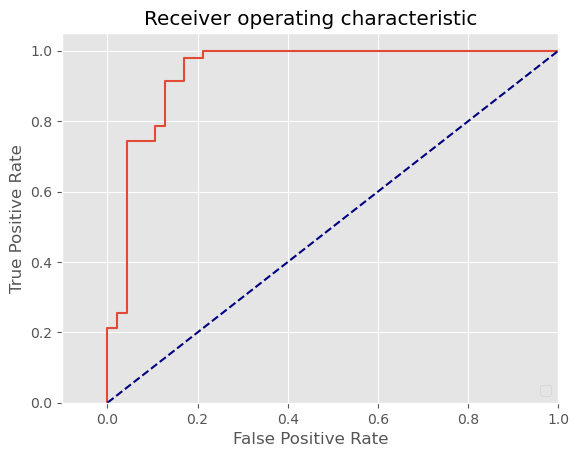

In [13]:
################# ROC curve

from sklearn.metrics import (roc_curve, auc, roc_auc_score, confusion_matrix)
import itertools

# auc scores
def get_auc_scores(clf, X_train, X_test, y_train, y_test):
	"Prints the AUC scores for training and testing data"
 
	y_train_score = clf.predict_proba(X_train)[:, 1]
	y_test_score = clf.predict_proba(X_test)[:, 1]
	
	auc_train = roc_auc_score(y_train, y_train_score)
	auc_test = roc_auc_score(y_test, y_test_score)
	
	print(f"Training AUC: {auc_train} Testing AUC: {auc_test}")
 
	return y_test_score

y_test_score_actual = get_auc_scores(clf, X_train, X_test, y_train, y_test)
print(y_test_score_actual)

# roc curve
def plot_roc_curve(y_test, y_test_score):
	"Plot ROC curve for testing data"
 
	fpr, tpr, _ = roc_curve(y_test, y_test_score)
	roc_auc = auc(fpr, tpr)
	plt.figure()
	#plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
	#plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)")
	plt.plot(fpr, tpr)
	#plt.plot([0, 1], [0, 1], "k — ")
	plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
	plt.xlim([-0.1, 1.0])
	plt.ylim([0.0, 1.05])
	plt.xlabel("False Positive Rate")
	plt.ylabel("True Positive Rate")
	plt.title("Receiver operating characteristic")
	plt.legend(loc="lower right")
	plt.show()
#	plt.savefig("/projects/b1073/u54/jdc_sandbox/ROC_curve.svg", format="svg")
    
## mv ROC_curve.svg ROC_curve_STXBP1model1_TEST_Nov2023.svg
plot_roc_curve(y_test, y_test_score_actual)

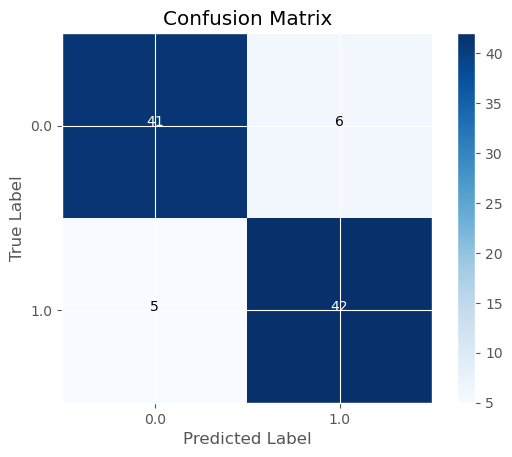

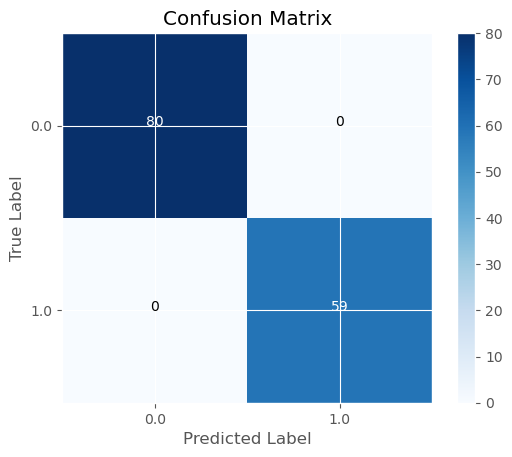

In [14]:
# confusion matrix

def show_cm(y_true, y_pred, class_names=None, model_name=None):
	"Show confusion matrix"
 
	cf = confusion_matrix(y_true, y_pred)
	plt.imshow(cf, cmap=plt.cm.Blues)
	if model_name:
		plt.title("Confusion Matrix: {}".format(model_name))
	else:
		plt.title("Confusion Matrix")
		plt.ylabel("True Label")
		plt.xlabel("Predicted Label")
	if class_names:
		tick_marks = np.arange(len(class_names))
		plt.xticks(tick_marks, class_names)
		plt.yticks(tick_marks, class_names)
	else:
		class_names = set(y_true)
		tick_marks = np.arange(len(class_names))
		plt.xticks(tick_marks, class_names)
		plt.yticks(tick_marks, class_names)

	thresh = cf.max() / 2.0

	for i, j in itertools.product(range(cf.shape[0]), range(cf.shape[1])):
		plt.text(j, i, cf[i, j], horizontalalignment="center", color="white" if cf[i, j] > thresh else "black",)
	plt.colorbar()
	plt.show()
#	plt.savefig("/projects/b1073/u54/jdc_sandbox/Conf_matrix.svg", format="svg")

# run on test set ## change names of file with mv in terminal in between runs
## mv Conf_matrix.svg Conf_matrix_STXBP1model1_TEST_Nov2023.svg
y_pred = clf.predict(X_test)
show_cm(y_test, y_pred, class_names=None, model_name=None)

# run on training set ## mv Conf_matrix.svg Conf_matrix_STXBP1model1_TRAIN_Nov2023.svg
y_pred = clf.predict(X_train)
show_cm(y_train, y_pred, class_names=None, model_name=None)


In [16]:
 # output data 

#dfs_copy = dfs.drop(['CLASS'], axis=1)

vus_score = clf.predict_proba(dfs.drop(['CLASS'], axis=1))

vus_score

final_df = df_copy
vus_score_df = pd.DataFrame(vus_score)
final_df['Prob_BLB'] = pd.to_numeric(vus_score_df[0])
final_df['Prob_PLP'] = pd.to_numeric(vus_score_df[1])

final_df
#output model 1
final_df.to_csv('/projects/b1073/u54/SLC6A1/newRun_jun2026/SLC6A1_ALLsnvs_wPROBmodel320est5dep.csv', index=False) 

In [205]:
# testing if shap works with current kernel ipykernel
#import shap ## nope T_T

clf
#########
######### END OF CURRENT VERSION OF NOTEBOOK
#########

GradientBoostingClassifier(learning_rate=0.5, n_estimators=20, random_state=0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   param_n_estimators  9 non-null      object 
 1   param_max_depth     9 non-null      object 
 2   mean_test_score     9 non-null      float64
 3   std_test_score      9 non-null      float64
 4   rank_test_score     9 non-null      int32  
dtypes: float64(2), int32(1), object(2)
memory usage: 456.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   param_n_estimators  9 non-null      object 
 1   param_max_depth     9 non-null      object 
 2   mean_test_score     9 non-null      float64
 3   std_test_score      9 non-null      float64
 4   rank_test_score     9 non-null      object 
dtypes: float64(2), object(3)
memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   param_n_estimators  9 non-null      object 
 1   param_max_depth     9 non-null      object 
 2   mean_test_score     9 non-null      float64
 3   std_test_score      9 non-null      float64
 4   rank_test_score     9 non-null      int32  
dtypes: float64(2), int32(1), object(2)
memory usage: 456.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   param_n_estimators  90 non-null     object 
 1   param_max_depth     90 non-null     object 
 2   mean_test_score     90 non-null     float64
 3   std_test_score      90 non-null     float64
 4   rank_test_score     90 non-null     object 
dtypes: float64(2), object(3)
memory usa

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   param_n_estimators  9 non-null      object 
 1   param_max_depth     9 non-null      object 
 2   mean_test_score     9 non-null      float64
 3   std_test_score      9 non-null      float64
 4   rank_test_score     9 non-null      int32  
dtypes: float64(2), int32(1), object(2)
memory usage: 456.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   param_n_estimators  171 non-null    object 
 1   param_max_depth     171 non-null    object 
 2   mean_test_score     171 non-null    float64
 3   std_test_score      171 non-null    float64
 4   rank_test_score     171 non-null    object 
dtypes: float64(2), object(3)
memory u

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   param_n_estimators  9 non-null      object 
 1   param_max_depth     9 non-null      object 
 2   mean_test_score     9 non-null      float64
 3   std_test_score      9 non-null      float64
 4   rank_test_score     9 non-null      int32  
dtypes: float64(2), int32(1), object(2)
memory usage: 456.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   param_n_estimators  252 non-null    object 
 1   param_max_depth     252 non-null    object 
 2   mean_test_score     252 non-null    float64
 3   std_test_score      252 non-null    float64
 4   rank_test_score     252 non-null    object 
dtypes: float64(2), object(3)
memory u

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   param_n_estimators  9 non-null      object 
 1   param_max_depth     9 non-null      object 
 2   mean_test_score     9 non-null      float64
 3   std_test_score      9 non-null      float64
 4   rank_test_score     9 non-null      int32  
dtypes: float64(2), int32(1), object(2)
memory usage: 456.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   param_n_estimators  333 non-null    object 
 1   param_max_depth     333 non-null    object 
 2   mean_test_score     333 non-null    float64
 3   std_test_score      333 non-null    float64
 4   rank_test_score     333 non-null    object 
dtypes: float64(2), object(3)
memory u

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   param_n_estimators  9 non-null      object 
 1   param_max_depth     9 non-null      object 
 2   mean_test_score     9 non-null      float64
 3   std_test_score      9 non-null      float64
 4   rank_test_score     9 non-null      int32  
dtypes: float64(2), int32(1), object(2)
memory usage: 456.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   param_n_estimators  414 non-null    object 
 1   param_max_depth     414 non-null    object 
 2   mean_test_score     414 non-null    float64
 3   std_test_score      414 non-null    float64
 4   rank_test_score     414 non-null    object 
dtypes: float64(2), object(3)
memory u

mean_test_score std_test_score  \
param_n_estimators param_max_depth                                  
10                 3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   
20                 3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   
40                 3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   
80                 3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   
160                3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   
320                3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   
500                3                           NaN            NaN   
                   4                           NaN            NaN   
                   5                           NaN            NaN   

                                   rank_test_score  \
param_n_estimators param_max_depth                   
10                 3                           NaN   
                   4                           NaN   
                   5                           NaN   
20                 3                           NaN   
                   4                           NaN   
                   5                           NaN   
40                 3                           NaN   
                   4                           NaN   
                   5                           NaN   
80                 3                           NaN   
                   4                           NaN   
                   5                           NaN   
160                3                           NaN   
                   4                           NaN   
                   5                           NaN   
320                3                           NaN   
                   4                           NaN   
                   5                           NaN   
500                3                           NaN   
                   4                           NaN   
                   5                           NaN   

                                    mean_test_neg_mean_absolute_error  \
param_n_estimators param_max_depth                                      
10                 3                                        -0.060750   
                   4                                        -0.062067   
                   5                                        -0.056983   
20                 3                                        -0.048733   
                   4                                        -0.047000   
                   5                                        -0.049067   
40                 3                                        -0.042083   
                   4                                        -0.043050   
                   5                                        -0.042783   
80                 3                                        -0.040250   
                   4                                        -0.038883   
                   5                                        -0.038783   
160                3                                        -0.036333   
                   4                                        -0.037950   
                   5                

RandomForestClassifier(max_depth=3, n_estimators=500, random_state=0)
neg_mean_absolute_error: 0.094 (0.292)
Accuracy: 0.906 (0.292)


[[24  4]
 [ 2 23]]
              precision    recall  f1-score   support

         0.0       0.92      0.86      0.89        28
         1.0       0.85      0.92      0.88        25

    accuracy                           0.89        53
   macro avg       0.89      0.89      0.89        53
weighted avg       0.89      0.89      0.89        53

0.8867924528301887
importance:
[5.67059944e-02 1.61879286e-03 1.72722204e-01 2.76997063e-02
 6.24550305e-03 1.52920218e-02 8.70251978e-04 6.91679257e-04
 8.99085543e-04 1.01165291e-03 2.94859582e-03 3.36023761e-03
 9.82862903e-06 2.28660928e-04 2.02687487e-03 6.65735023e-04
 1.32431177e-03 1.89961439e-03 5.03381040e-03 5.77251928e-02
 1.13412452e-01 9.40520413e-03 3.79848829e-03 1.69504270e-03
 3.45414131e-02 5.41626896e-03 5.27999497e-02 1.52737447e-02
 3.56718309e-02 6.82021888e-02 1.30918830e-01 5.75805579e-02
 2.21684101e-02 4.01618103e-02 3.32811142e-03 7.60057077e-03
 1.03752317e-03 3.78037005e-04 1.42273085e-04 2.55909359e-02
 1.18966037e-

In [ ]:
#### ROC curve code I cannot sort out
#### our data

# trying to figure out new ROC curve with CV incorporated

# lets try ROC w CV from https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc_crossval.html
# and modify
## ok now we modify and try to get working on our data

import numpy as np
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import auc
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold



X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

cv = StratifiedKFold(n_splits=5)
#classifier = svm.SVC(kernel="linear", probability=True, random_state=random_state)
classifier = RandomForestClassifier(n_estimators=80, max_depth=4, random_state=0)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(6, 6))
for fold, (train, test) in enumerate(cv.split(X, y)):
    classifier.fit(X_train_np[train], y_train_np[train])
    viz = RocCurveDisplay.from_estimator(
        classifier,
        X_test_np[test],
        y_test_np[test],
        name=f"ROC fold {fold}",
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)
ax.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=f"Mean ROC curve with variability\n(Positive label '{target_names[1]}')",
)
ax.axis("square")
ax.legend(loc="lower right")
plt.show()

In [ ]:
#### ROC curve code I cannot sort out
#### example

# trying to figure out ROC curve appropriate for LOOCV

# lets try ROC w CV from https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc_crossval.html
# and modify ## but first run code and make sure it works ## it does if I switch to kernel with latest scikitlearn

import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
target_names = iris.target_names
X, y = iris.data, iris.target
X, y = X[y != 2], y[y != 2]
n_samples, n_features = X.shape

print(type(X))
print(type(y))

random_state = np.random.RandomState(0)
X = np.concatenate([X, random_state.randn(n_samples, 200 * n_features)], axis=1)

import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import auc
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=6)
classifier = svm.SVC(kernel="linear", probability=True, random_state=random_state)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(6, 6))
for fold, (train, test) in enumerate(cv.split(X, y)):
    classifier.fit(X[train], y[train])
    viz = RocCurveDisplay.from_estimator(
        classifier,
        X[test],
        y[test],
        name=f"ROC fold {fold}",
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)
ax.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=f"Mean ROC curve with variability\n(Positive label '{target_names[1]}')",
)
ax.axis("square")
ax.legend(loc="lower right")
plt.show()

In [26]:
############################
###### Start old code ###### 
############################

# Split data in train set and test set

X = dfs.drop(['CLASS'], axis=1)
y = dfs['CLASS']




In [26]:
# Decision Tree

# RandomForests

from sklearn.ensemble import RandomForestClassifier

# grid search tuned | top scorer
clf = RandomForestClassifier(n_estimators=80, max_depth=4, random_state=0).fit(X_train, y_train)

# grid search tuned | second best
#clf = RandomForestClassifier(n_estimators=20, max_depth=4, random_state=0).fit(X_train, y_train)

#clf.fit(X_train, y_train)
#y_pred = clf.predict(X_test)


# evaluation

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# print(confusion_matrix(y_test,y_pred.round()))
# print(classification_report(y_test,y_pred.round()))
# print(accuracy_score(y_test, y_pred.round()))

# ValueError: Classification metrics can't handle a mix of binary and continuous targets

# get importance
# importance = clf.feature_importances_
# print('importance:')
# print(importance)

#########################

# Gradient Tree Boosting

from sklearn.ensemble import GradientBoostingClassifier

# grid search tuned | top scorer
clf = GradientBoostingClassifier(n_estimators=40, learning_rate=0.4, max_depth=3, random_state=42).fit(X_train, y_train)

# grid search tuned | second best
#clf = GradientBoostingClassifier(n_estimators=80, learning_rate=0.4, max_depth=3, random_state=42).fit(X_train, y_train)

#clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# evaluation

print(confusion_matrix(y_test,y_pred.round()))
print(classification_report(y_test,y_pred.round()))
print(accuracy_score(y_test, y_pred.round()))

# get importance
importance = clf.feature_importances_
print('importance:')
print(importance)

[[18  2]
 [ 3 11]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        20
           1       0.85      0.79      0.81        14

   micro avg       0.85      0.85      0.85        34
   macro avg       0.85      0.84      0.85        34
weighted avg       0.85      0.85      0.85        34

0.8529411764705882
importance:
[4.71450965e-04 3.58874527e-04 0.00000000e+00 3.77063700e-03
 6.02988642e-06 4.43093589e-03 7.75425017e-03 1.32202412e-02
 1.88921673e-02 1.02644271e-03 7.33620034e-05 4.87300488e-03
 1.54497772e-02 5.85927472e-03 6.40709316e-02 1.14100474e-02
 1.74976854e-03 2.19718419e-03 2.39713656e-02 4.97192944e-03
 4.22302701e-01 1.94290336e-01 4.58401033e-02 5.13019978e-03
 1.08785417e-01 1.26117564e-02 2.64818115e-02]


In [27]:
#################

# evaluating Random Forest w Gradient Boosting ## 5x3

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import ShuffleSplit

n_samples = X.shape[0]
scores = np.zeros(15, dtype=np.float32)

# loop didn't want to work :(
cv = ShuffleSplit(n_splits=3, test_size=0.15, random_state=0)
scores[0] = cross_val_score(clf, X_train, y_train, cv=cv)[0]
scores[1] = cross_val_score(clf, X_train, y_train, cv=cv)[1]
scores[2] = cross_val_score(clf, X_train, y_train, cv=cv)[2]
cv = ShuffleSplit(n_splits=3, test_size=0.15, random_state=1)
scores[3] = cross_val_score(clf, X_train, y_train, cv=cv)[0]
scores[4] = cross_val_score(clf, X_train, y_train, cv=cv)[1]
scores[5] = cross_val_score(clf, X_train, y_train, cv=cv)[2]
cv = ShuffleSplit(n_splits=3, test_size=0.15, random_state=2)
scores[6] = cross_val_score(clf, X_train, y_train, cv=cv)[0]
scores[7] = cross_val_score(clf, X_train, y_train, cv=cv)[1]
scores[8] = cross_val_score(clf, X_train, y_train, cv=cv)[2]
cv = ShuffleSplit(n_splits=3, test_size=0.15, random_state=3)
scores[9] = cross_val_score(clf, X_train, y_train, cv=cv)[0]
scores[10] = cross_val_score(clf, X_train, y_train, cv=cv)[1]
scores[11] = cross_val_score(clf, X_train, y_train, cv=cv)[2]
cv = ShuffleSplit(n_splits=3, test_size=0.15, random_state=4)
scores[12] = cross_val_score(clf, X_train, y_train, cv=cv)[0]
scores[13] = cross_val_score(clf, X_train, y_train, cv=cv)[1]
scores[14] = cross_val_score(clf, X_train, y_train, cv=cv)[2]

print(scores)
print('Mean from 5x3 cross validation')
print(np.mean(scores))
print('Standard deviation from 5x3 cross validation')
print(np.std(scores))
#print(cross_val_score(clf, X_train, y_train, scoring="accuracy", cv=3))


from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

#y_pred = cross_val_predict(clf, X_train, y_train, cv=3, method="predict")
#print(y_pred)
#print(confusion_matrix(y_train, y_pred))




[0.79310346 0.86206895 0.8965517  0.9655172  0.8965517  0.86206895
 1.         0.86206895 0.8965517  0.8965517  0.86206895 0.7586207
 0.8965517  0.8965517  0.82758623]
Mean from 5x3 cross validation
0.878161
Standard deviation from 5x3 cross validation
0.05751722


In [11]:
########

# grid search

from sklearn.model_selection import GridSearchCV

# comment out when done
# clf = RandomForestClassifier()
clf = GradientBoostingClassifier()

# param_dict = {
#         "n_estimators":[1,2,3,4,5,10,20,40,80],
#         "max_depth":range(3,5),
#     }
    
param_dict = {
        "n_estimators":[1,2,3,4,5,10,20,40,80],
        "max_depth":range(3,5),
        "learning_rate":[0.1,0.2,0.3,0.4,0.5]
    }

# temporarily commented out to save time
# grid_search = GridSearchCV(clf, param_grid=param_dict, cv=3,verbose=1,n_jobs=-1)
# grid_search.fit(X_train, y_train)
# print(grid_search.best_params_)

gs_df = pd.DataFrame()
i=0

# for normal RF
# while i < 1000:
#     grid_search = GridSearchCV(clf, param_grid=param_dict, cv=3,verbose=0,n_jobs=-1)
#     grid_search.fit(X_train, y_train)
#     cvres = pd.DataFrame(grid_search.cv_results_)
#     cv_results_tiny = cvres[['param_n_estimators', 'param_max_depth', 'rank_test_score']]
#     gs_df=gs_df.append(cv_results_tiny.sort_values(by='rank_test_score', ascending=True).head(1))
#     i += 1
#     print(i)
    
# for boosted
while i < 1000:
    grid_search = GridSearchCV(clf, param_grid=param_dict, cv=3,verbose=0,n_jobs=-1)
    grid_search.fit(X_train, y_train)
    cvres = pd.DataFrame(grid_search.cv_results_)
    cv_results_tiny = cvres[['param_n_estimators', 'param_max_depth', 'param_learning_rate', 'rank_test_score']]
    gs_df=gs_df.append(cv_results_tiny.sort_values(by='rank_test_score', ascending=True).head(1))
    i += 1
    print(i)

print('done')

/software/qanalytics/jupyterhub/env/lib/python3.7/site-packages/sklearn/model_selection/_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


1


/software/qanalytics/jupyterhub/env/lib/python3.7/site-packages/sklearn/model_selection/_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


2


/software/qanalytics/jupyterhub/env/lib/python3.7/site-packages/sklearn/model_selection/_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


...

/software/qanalytics/jupyterhub/env/lib/python3.7/site-packages/sklearn/model_selection/_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


998


/software/qanalytics/jupyterhub/env/lib/python3.7/site-packages/sklearn/model_selection/_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


999
1000
done


/software/qanalytics/jupyterhub/env/lib/python3.7/site-packages/sklearn/model_selection/_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


In [14]:
#df.head

gs_dfs = gs_df.loc[gs_df['param_max_depth'] == 5]

gs_dfs.groupby(gs_df.columns.tolist(),as_index=False).size()

#gs_dfs = gs_df.loc[gs_df['param_max_depth'] == 3]

#gs_dfs.groupby(gs_df.columns.tolist(),as_index=False).size()

#gs_dfs = gs_df.loc[gs_df['param_max_depth'] == 4]

#gs_dfs.groupby(gs_df.columns.tolist(),as_index=False).size()

#gs_dfs = gs_df.loc[gs_df['param_max_depth'] == 5]

#gs_dfs.groupby(gs_df.columns.tolist(),as_index=False).size()

Series([], dtype: int64)

No handles with labels found to put in legend.


Training AUC: 1.0 Testing AUC: 0.9214285714285715
[9.81597802e-01 7.33834917e-01 5.56999522e-01 2.48059061e-03
 4.75393770e-04 2.12342859e-04 9.67154686e-03 2.38427051e-01
 1.72848466e-01 9.97884222e-01 2.34612070e-03 9.99938856e-01
 4.40483643e-01 9.98882541e-01 1.98668481e-03 6.45429803e-03
 6.22146095e-01 9.98833663e-01 1.86165877e-04 8.92675839e-04
 8.13000670e-04 7.52922148e-05 2.42892219e-03 1.14674062e-01
 9.99261428e-01 9.99167941e-01 9.99224095e-01 5.48247302e-01
 6.33250866e-04 9.99516654e-01 2.62462380e-04 4.17427203e-04
 4.68684611e-03 1.14701563e-04]


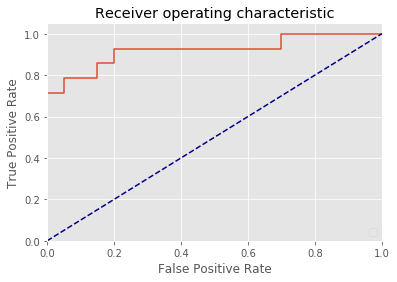

In [28]:
#################

from sklearn.metrics import (roc_curve, auc, roc_auc_score, confusion_matrix)
import itertools

# auc scores
def get_auc_scores(clf, X_train, X_test, y_train, y_test):
	"Prints the AUC scores for training and testing data"
 
	y_train_score = clf.predict_proba(X_train)[:, 1]
	y_test_score = clf.predict_proba(X_test)[:, 1]
	
	auc_train = roc_auc_score(y_train, y_train_score)
	auc_test = roc_auc_score(y_test, y_test_score)
	
	print(f"Training AUC: {auc_train} Testing AUC: {auc_test}")
 
	return y_test_score

y_test_score_actual = get_auc_scores(clf, X_train, X_test, y_train, y_test)
print(y_test_score_actual)

# roc curve
def plot_roc_curve(y_test, y_test_score):
	"Plot ROC curve for testing data"
 
	fpr, tpr, _ = roc_curve(y_test, y_test_score)
	roc_auc = auc(fpr, tpr)
	plt.figure()
	#plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
	#plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)")
	plt.plot(fpr, tpr)
	#plt.plot([0, 1], [0, 1], "k — ")
	plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
	plt.xlim([0.0, 1.0])
	plt.ylim([0.0, 1.05])
	plt.xlabel("False Positive Rate")
	plt.ylabel("True Positive Rate")
	plt.title("Receiver operating characteristic")
	plt.legend(loc="lower right")
	plt.show()

plot_roc_curve(y_test, y_test_score_actual)

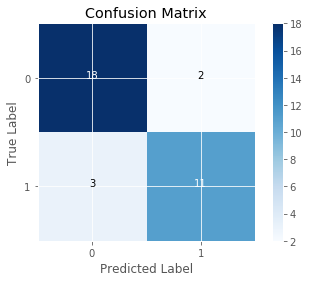

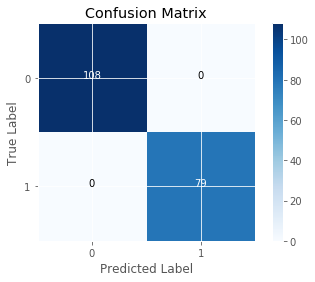

In [29]:
# confusion matrix

def show_cm(y_true, y_pred, class_names=None, model_name=None):
	"Show confusion matrix"
 
	cf = confusion_matrix(y_true, y_pred)
	plt.imshow(cf, cmap=plt.cm.Blues)
	if model_name:
		plt.title("Confusion Matrix: {}".format(model_name))
	else:
		plt.title("Confusion Matrix")
		plt.ylabel("True Label")
		plt.xlabel("Predicted Label")
	if class_names:
		tick_marks = np.arange(len(class_names))
		plt.xticks(tick_marks, class_names)
		plt.yticks(tick_marks, class_names)
	else:
		class_names = set(y_true)
		tick_marks = np.arange(len(class_names))
		plt.xticks(tick_marks, class_names)
		plt.yticks(tick_marks, class_names)

	thresh = cf.max() / 2.0

	for i, j in itertools.product(range(cf.shape[0]), range(cf.shape[1])):
		plt.text(j, i, cf[i, j], horizontalalignment="center", color="white" if cf[i, j] > thresh else "black",)
	plt.colorbar()
	plt.show()

y_pred = clf.predict(X_test)
show_cm(y_test, y_pred, class_names=None, model_name=None)
y_pred = clf.predict(X_train)
show_cm(y_train, y_pred, class_names=None, model_name=None)


In [30]:
# validation --> probabilities for BLB / PLP

X = dfs.drop(['CLASS'], axis=1)
y = dfs['CLASS']

print(clf.predict(X))

print(clf.predict_proba(X))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[[9.95538639e-01 4.46136121e-03]
 [9.99141491e-01 8.58508838e-04]
 [9.99858881e-01 1.41119098e-04]
 [9.99877794e-01 1.22205706e-04]
 [9.99925765e-01 7.42349146e-05]
 [9.99533817e-01 4.66182718e-04]
 [9.99169390e-01 8.30609883e-04]
 [9.94303683e-01 5.69631746e-03]
 [9.92501987e-01 7.49801254e-03]
 [9.98045088e-01 1.95491242e-03]
 [9.96568601e-01 3.43139935e-03]
 [9.96325802e-01 3.67419784e-03]
 [9.98346781e-01 1.65321932e-03]
 [9.88589420e-01 1.14105804e-02]
 [9.99879510e-01 1.20489697e-04]
 [9.99742716e-01 2.57283614e-04]
 [9.99491836e-01 5.0816

In [31]:
# validation --> probabilities for VUS

## VUS

## import data --> already imported above!!
#df = pd.read_csv("/projects/b1073/u54/vus_final_stxbp1_iMutant.txt", delimiter="\t")

# Preview the first 5 lines of the loaded data 
#print(df.head())

# Tidy data | filter out BLB (class = 0) and PLP (class = 1); keep VUS (class = 2)
df.info()
df_filtered = df[df['CLASS'] >= 2]
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 28 columns):
IMUTANT                       354 non-null float64
HYDROPATHY_ALT_SCORE          354 non-null int64
H_ALTMREF                     354 non-null int64
C_ALTMREF                     354 non-null int64
P_ALTMREF                     354 non-null int64
S_ALTMREF                     354 non-null int64
GRANTHAM_SCORES               354 non-null int64
BLOSUM62                      354 non-null int64
GERP++_RS                     354 non-null float64
SIPHY_29WAY_LOGODDS           354 non-null float64
PHASTCONS100WAY_VERTEBRATE    354 non-null float64
PHYLOP100WAY_VERTEBRATE       354 non-null float64
CAM_MEAN                      354 non-null float64
CAM_MEDIAN                    354 non-null float64
CAM_OVERALL                   354 non-null float64
CAM_MEAN_SW                   354 non-null float64
CAM_MEDIAN_SW                 354 non-null float64
CAM_OVERALL_SW                354 non-null

In [32]:
# standardization

dfs = df_filtered
print(dfs.head())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# temporarily removing STRUM since server is down and we don't have that data yet
#dfs[['Hydropathy_REF_Score', 'Hydropathy_ALT_Score', 'H_ALTmREF', 'Charge_REF_Score', 'Charge_ALT_Score', 'C_ALTmREF', 'Polarity_REF_Score', 'Polarity_ALT_Score', 'P_ALTmREF', 'Shape_REF_Score', 'Shape_ALT_Score', 'S_ALTmREF', 'Grantham_Scores', 'BLOSUM62', 'GERP++_RS', 'SiPhy_29way_logOdds', 'phastCons20way_mammalian', 'phyloP20way_mammalian', 'STRUM_ddG', 'iMutant_ddG']] = scaler.fit_transform(dfs[['Hydropathy_REF_Score', 'Hydropathy_ALT_Score', 'H_ALTmREF', 'Charge_REF_Score', 'Charge_ALT_Score', 'C_ALTmREF', 'Polarity_REF_Score', 'Polarity_ALT_Score', 'P_ALTmREF', 'Shape_REF_Score', 'Shape_ALT_Score', 'S_ALTmREF', 'Grantham_Scores', 'BLOSUM62', 'GERP++_RS', 'SiPhy_29way_logOdds', 'phastCons20way_mammalian', 'phyloP20way_mammalian', 'STRUM_ddG', 'iMutant_ddG']])
dfs[['IMUTANT', 'GRANTHAM_SCORES', 'BLOSUM62', 'GERP++_RS', 'SIPHY_29WAY_LOGODDS', 'PHASTCONS100WAY_VERTEBRATE', 'PHYLOP100WAY_VERTEBRATE', 'CAM_MEAN', 'CAM_MEDIAN', 'CAM_OVERALL', 'CAM_MEAN_SW', 'CAM_MEDIAN_SW', 'CAM_OVERALL_SW', 'METALR_SCORE', 'METASVM_SCORE', 'M-CAP_SCORE', 'MUTPRED_SCORE', 'MUTATIONASSESSOR_SCORE', 'CADD_PHRED', 'RSA', 'MCSM_DDG', 'MAESTRO_DDG']] = scaler.fit_transform(dfs[['IMUTANT', 'GRANTHAM_SCORES', 'BLOSUM62', 'GERP++_RS', 'SIPHY_29WAY_LOGODDS', 'PHASTCONS100WAY_VERTEBRATE', 'PHYLOP100WAY_VERTEBRATE', 'CAM_MEAN', 'CAM_MEDIAN', 'CAM_OVERALL', 'CAM_MEAN_SW', 'CAM_MEDIAN_SW', 'CAM_OVERALL_SW', 'METALR_SCORE', 'METASVM_SCORE', 'M-CAP_SCORE', 'MUTPRED_SCORE', 'MUTATIONASSESSOR_SCORE', 'CADD_PHRED', 'RSA', 'MCSM_DDG', 'MAESTRO_DDG']])


print(dfs.head())

X = dfs.drop(['CLASS'], axis=1)
y = dfs['CLASS']

print(clf.predict(X))

print(clf.predict_proba(X))

     IMUTANT  HYDROPATHY_ALT_SCORE  H_ALTMREF  C_ALTMREF  P_ALTMREF  \
221    -1.02                    -1          0          0          0   
222    -0.81                     1          0          2          0   
223    -1.74                     0         -1          0         -1   
224    -3.72                     1         -2          1         -2   
225    -1.09                     1          0          0          0   

     S_ALTMREF  GRANTHAM_SCORES  BLOSUM62  GERP++_RS  SIPHY_29WAY_LOGODDS  \
221          0               64        -1       2.70               8.9334   
222          0               56         1       2.70               7.1361   
223          0               60        -1       2.70               8.9334   
224         -1              152        -3       1.37               5.2053   
225          0               45         2       1.77               4.7859   

        ...       CLASS  METALR_SCORE  METASVM_SCORE  M-CAP_SCORE  \
221     ...           2        0.4303    